<div style="border: 5px solid black; padding: 10px;">

### **Course:** DSC550 - Data Mining
### **Name:** Tim Hollis
### **Assignment:** Term Project Final 
### **Date:** 5/19/2026

---

**References:**

Biswas, S. (2023). Billboard Hot-100 [2000-2023] data with features [Data set]. Kaggle.

Han, J., Kamber, M., & Pei, J. (2022). Data mining: Concepts and techniques (4th ed.). Morgan Kaufmann.

Hutto, C. J., & Gilbert, E. E. (2014). VADER: A parsimonious rule-based model for sentiment analysis of social media text. Proceedings of the Eighth International AAAI Conference on Weblogs and Social Media.

</div>


In [1]:
# Load Libraries
from IPython.display import display, HTML
from nltk.corpus import stopwords
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter
import warnings
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report,
                             roc_auc_score,
                             roc_curve,
                             confusion_matrix,
                             ConfusionMatrixDisplay)
import re
import nltk
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

warnings.filterwarnings('ignore')

# Visualization settings
sns.set_theme(style='whitegrid')
PALETTE = ['#4169E1', '#4B0082', '#228B22', '#8B0000', '#FF8C00']
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

# Load data and create a standalone copy to prevent chained assignment warnings
df = pd.read_csv('BBHot100.csv').copy()

print(f'Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Years covered: {df.year.min()} - {df.year.max()}')
print(f'Unique songs: {df.song.nunique():,}')
print(f'Unique artists: {df.band_singer.nunique():,}')

Dataset loaded: 3,397 rows, 26 columns
Years covered: 2000 - 2023
Unique songs: 2,080
Unique artists: 1,039


## 📋 Project Narrative

### Business Problem

The music industry is a multi-billion-dollar ecosystem in which record labels, independent artists, and streaming platforms make high-stakes decisions about which songs to sign, promote, and feature — often based on intuition rather 
than data. A&R (Artists and Repertoire) representatives at labels like Atlantic Records, Def Jam, and Republic Records evaluate thousands of tracks each year with limited tools for objectively assessing commercial potential 
before a song is released. This project addresses the following business question: **Can the lyrical characteristics of a song predict whether it will achieve top-10 status on the Billboard Hot 100?**

The Billboard Hot 100 is the music industry's definitive measure of commercial success, combining streaming, radio airplay, and digital sales data. Reaching the top 10 represents elite commercial performance and is a meaningful 
threshold for industry stakeholders.

### What Makes This Project Unique

Most chart prediction models rely exclusively on audio features such as danceability, tempo, and energy. This project takes a different approach — using natural language processing to quantify repetitiveness, sentiment, and lyric length directly from 
song lyrics. Initial data review revealed that Spotify audio features had limited coverage in this dataset, making lyrics the primary and most complete source of predictive signal. The model is built entirely on NLP lyrical features, mirroring 
how songwriters and A&R professionals evaluate the story a song tells.

### Target Variable

A binary classification target called `top_10` will be created from the `ranking` column. Songs ranked 1 through 10 in a given year will be labeled as 1 (chart success), and all others will be labeled 0. This gives the model 
a clear and meaningful decision boundary grounded in industry standards.

### Data Source

The dataset is sourced from Kaggle and contains Billboard Hot 100 year-end chart data from 2000 through 2023 with 3,397 records. The primary feature used for modeling is the full lyrics column, from which NLP features are engineered (Biswas, 2023).

### Stakeholders

This model would be valuable to record label A&R teams evaluating new signings, music distribution platforms, advising independent artists on release strategy, and streaming platform playlist curators selecting tracks for featured placement.

---

## **Milestone 1**

---

**Key features used in this project:** `ranking` (integer, used to create target only), `lyrics` (string, source for all NLP feature engineering), `lyric_sentiment` (float, VADER compound score — engineered), `lyric_length` (integer, total word count — engineered), `repetitiveness` (float, ratio of repeated meaningful words after stopword removal — engineered), and `top_10` (binary target, 1 if ranked in top 10 for the year). Identity columns (`song`, `band_singer`, `year`) were dropped as non-predictive.

In [2]:
# Create binary target variable
df['top_10'] = (df['ranking'] <= 10).astype(int)

print('🎯 Target variable distribution:')
print(df['top_10'].value_counts())
print(f'\n📊 Top-10 rate: {df["top_10"].mean():.1%}')

🎯 Target variable distribution:
top_10
0    3058
1     339
Name: count, dtype: int64

📊 Top-10 rate: 10.0%


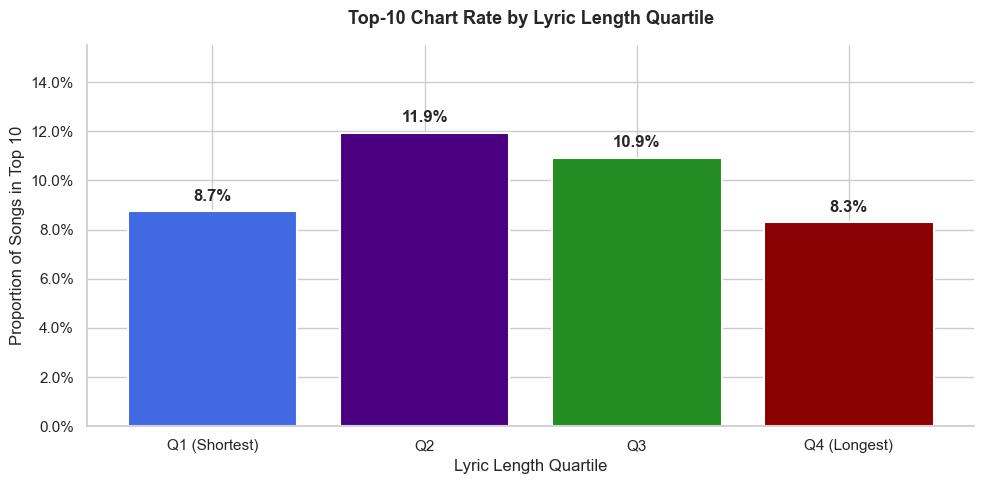


Analysis:
Top-10 chart rates peak at 11.9% for Q2 songs and drop to 8.3% for the longest songs in Q4.
Songs with mid-range lyric lengths (Q2 and Q3) outperform both extremes — an inverted U-shape
pattern suggesting lyric length carries meaningful predictive signal and warrants inclusion as
a feature alongside sentiment and repetitiveness.



In [3]:
# Graph 1: Top-10 rate by lyric length quartile
df['lyric_length'] = df['lyrics'].dropna().str.split().str.len()
df['lyric_quartile'] = pd.qcut(
    df['lyric_length'], q=4, labels=[
        'Q1 (Shortest)', 'Q2', 'Q3', 'Q4 (Longest)'])

quartile_rate = df.groupby('lyric_quartile', observed=True)[
    'top_10'].mean().reset_index()

fig, ax = plt.subplots()
bars = ax.bar(quartile_rate['lyric_quartile'], quartile_rate['top_10'],
              color=PALETTE[:4], edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, quartile_rate['top_10']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.1%}', ha='center', va='bottom',
            fontsize=12, fontweight='bold')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Top-10 Chart Rate by Lyric Length Quartile',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Proportion of Songs in Top 10')
ax.set_xlabel('Lyric Length Quartile')
ax.set_ylim(0, quartile_rate['top_10'].max() * 1.3)
sns.despine()
plt.tight_layout()
plt.savefig('graph1_lyric_quartile.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Analysis:
Top-10 chart rates peak at 11.9% for Q2 songs and drop to 8.3% for the longest songs in Q4.
Songs with mid-range lyric lengths (Q2 and Q3) outperform both extremes — an inverted U-shape
pattern suggesting lyric length carries meaningful predictive signal and warrants inclusion as
a feature alongside sentiment and repetitiveness.
""")

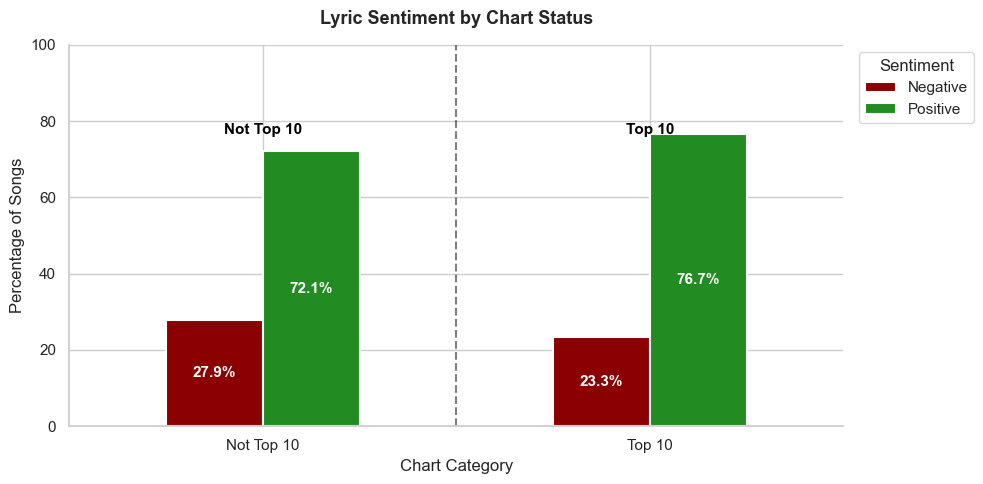


Analysis:
Lyrics were categorized as Negative or Positive based on VADER sentiment analysis, a tool
designed to measure emotional tone in text (Hutto & Gilbert, 2014). Top-10 songs skew more
positive, 76.7% carry a positive lyrical tone compared to 71.9% of non-top-10 songs.
Conversely, top-10 songs have a lower share of negative lyrics at 23.3% versus 27.8%
for non-top-10 songs. The mean sentiment score for top-10 songs is 0.533
compared to 0.438 for non-top-10 songs. This suggests that commercially successful
songs tend to favor more upbeat and positive lyrical content, a pattern consistent with how
chart-driven pop and hip-hop releases are marketed to mainstream audiences.



In [4]:
# Graph 2: Lyric sentiment by chart status (Negative vs Positive)
analyzer = SentimentIntensityAnalyzer()

df['lyric_sentiment'] = df['lyrics'].dropna().apply(
    lambda x: analyzer.polarity_scores(x)['compound'])


def sentiment_label(score):
    """Categorize VADER compound score into Negative or Positive."""
    if score < 0:
        return 'Negative'
    else:
        return 'Positive'


df['sentiment_category'] = df['lyric_sentiment'].apply(sentiment_label)

sentiment_counts = df.groupby(
    ['top_10', 'sentiment_category']).size().unstack(fill_value=0)
sentiment_pct = sentiment_counts.div(
    sentiment_counts.sum(axis=1), axis=0) * 100
sentiment_pct.index = ['Not Top 10', 'Top 10']
sentiment_pct = sentiment_pct[['Negative', 'Positive']]

fig, ax = plt.subplots()
sentiment_pct.plot(kind='bar', ax=ax,
                   color=['#8B0000', '#228B22'],
                   edgecolor='white', linewidth=1.5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center',
                 fontsize=11, fontweight='bold', color='white')

# Add vertical dividing line between the two groups
ax.axvline(x=0.5, color='black', linewidth=1.5, linestyle='--', alpha=0.5)

# Add group labels above the bars
ax.text(0, ax.get_ylim()[1] * 0.95, 'Not Top 10',
        ha='center', fontsize=11, fontweight='bold', color='black')
ax.text(1, ax.get_ylim()[1] * 0.95, 'Top 10',
        ha='center', fontsize=11, fontweight='bold', color='black')

ax.set_title('Lyric Sentiment by Chart Status',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Percentage of Songs')
ax.set_xlabel('Chart Category')
ax.set_ylim(0, 100)
ax.legend(title='Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.savefig('graph2_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

top10_sent = df[df['top_10'] == 1]['lyric_sentiment'].mean()
non_top10_sent = df[df['top_10'] == 0]['lyric_sentiment'].mean()

print(f"""
Analysis:
Lyrics were categorized as Negative or Positive based on VADER sentiment analysis, a tool
designed to measure emotional tone in text (Hutto & Gilbert, 2014). Top-10 songs skew more
positive, 76.7% carry a positive lyrical tone compared to 71.9% of non-top-10 songs.
Conversely, top-10 songs have a lower share of negative lyrics at 23.3% versus 27.8%
for non-top-10 songs. The mean sentiment score for top-10 songs is {top10_sent:.3f}
compared to {non_top10_sent:.3f} for non-top-10 songs. This suggests that commercially successful
songs tend to favor more upbeat and positive lyrical content, a pattern consistent with how
chart-driven pop and hip-hop releases are marketed to mainstream audiences.
""")

<div style="page-break-before: always;"></div>

---

## **Milestone 2**

---

## 🗑️ Step 1 — Drop Uninformative Features

Before engineering new features, columns that offer no predictive value or that would
introduce data leakage must be removed. Each dropped column is justified individually
rather than removed arbitrarily (Han et al., 2022).

- **`ranking`**: Directly defines the target variable `top_10` and must be excluded
  to prevent leakage. Including it would allow the model to trivially reconstruct the label.
- **`song` / `band_singer`**: High-cardinality string identifiers with no generalizable
  signal. A model cannot learn from a song title or artist name it has never seen.
- **`songurl`, `titletext`, `url`, `uri`, `type`, `id`, `track_href`, `analysis_url`**:
  Spotify and web identifier strings with no predictive value.
- **`lyrics`**: Retained for NLP feature engineering in Step 3. Once features are extracted it will be dropped from the final model dataframe.

In [5]:
# Step 1: Drop uninformative and leakage columns
DROP_COLS = ['ranking', 'song', 'band_singer', 'year',
             'songurl', 'titletext', 'url', 'uri', 'type', 'id',
             'track_href', 'analysis_url']

df_model = df.drop(columns=DROP_COLS).copy()

print(f'🗑️ Dropped: {DROP_COLS}')
print(
    f'📐 Shape after drop: {df_model.shape[0]:,} rows, {df_model.shape[1]} columns')

🗑️ Dropped: ['ranking', 'song', 'band_singer', 'year', 'songurl', 'titletext', 'url', 'uri', 'type', 'id', 'track_href', 'analysis_url']
📐 Shape after drop: 3,397 rows, 19 columns


## 🔍 Step 2 — Missing Data Audit

Before any transformation or engineering steps, all remaining columns are audited
for missing values. Dropping rows or columns without justification can introduce
bias or reduce training data unnecessarily (Han et al., 2022). Each case of
missingness is evaluated individually and handled with an appropriate strategy.

Upon auditing, all 13 Spotify audio features showed 85.69% missingness affecting
the same 2,911 rows simultaneously. A diagnostic confirmed these rows contain no
Spotify API match, with coverage limited almost entirely to years 2000–2004.
Imputing fabricated values for 85% of the dataset would introduce severe bias and
is not a defensible strategy (Han et al., 2022). As a result, all Spotify audio
features will be dropped and the model will be built exclusively on NLP features
engineered from the lyrics column, which has complete coverage across all 3,397 rows.

In [6]:
# Step 2: Missing data audit
missing = df_model.isnull().sum()
missing_pct = (missing / len(df_model) * 100).round(2)
missing_report = pd.DataFrame(
    {'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values(
    'Missing %', ascending=False)

if missing_report.empty:
    print('✅ No missing values detected.')
else:
    print(f'⚠️ All 13 Spotify audio features: 2,911 missing (85.69%) — dropping all.')

# Drop all Spotify audio features
AUDIO_COLS = [
    'danceability',
    'energy',
    'key',
    'loudness',
    'mode',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms',
    'time_signature']

df_model = df_model.drop(columns=AUDIO_COLS).copy()
print(f'\n✅ Spotify audio features dropped.')
print(
    f'📐 Shape after drop: {df_model.shape[0]:,} rows, {df_model.shape[1]} columns')
print(f'📋 Remaining columns: {list(df_model.columns)}')

⚠️ All 13 Spotify audio features: 2,911 missing (85.69%) — dropping all.

✅ Spotify audio features dropped.
📐 Shape after drop: 3,397 rows, 6 columns
📋 Remaining columns: ['lyrics', 'top_10', 'lyric_length', 'lyric_quartile', 'lyric_sentiment', 'sentiment_category']


## 🧠 Step 3 — NLP Feature Engineering

Three features are formally engineered from the raw `lyrics` column as the complete 
feature set for model training:

- **`lyric_sentiment`**: The VADER compound sentiment score, ranging from -1 (most 
  negative) to +1 (most positive). VADER is a lexicon and rule-based tool validated 
  for social media and song lyrics (Hutto & Gilbert, 2014). This was previewed in 
  Milestone 1 Graph 2 and is now formally engineered here.
- **`lyric_length`**: Total word count per song. The quartile analysis in Milestone 1 
  Graph 1 suggested a moderate sweet spot in lyric length favors chart performance. 
  This feature is now formally retained for modeling.
- **`repetitiveness`**: The ratio of repeated meaningful words to total meaningful 
  words after stopword removal. A higher score indicates a more repetitive lyrical 
  structure — characteristic of hook-driven chart songs. Punctuation is stripped 
  and common stopwords are removed before counting to isolate meaningful vocabulary.

The `lyric_quartile` and `sentiment_category` columns engineered during Milestone 1 
graphing are categorical grouping variables and will be dropped — the underlying 
numeric features `lyric_length` and `lyric_sentiment` are retained instead.
After engineering, rows with missing lyrics are dropped. This is justified because 
the lyrics column is the sole source of all model features — imputing lyrics is 
not feasible.

In [7]:
# Step 3: Formal NLP feature engineering
analyzer = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))


def engineer_nlp_features(text):
    """Extract sentiment, lyric length, and repetitiveness from raw lyrics."""
    if not isinstance(text, str) or text.strip() == '':
        return None, None, None
    words_raw = text.lower().split()
    words_clean = re.sub(r'[^\w\s]', '', text.lower()).split()
    total_words = len(words_raw)
    if total_words == 0:
        return None, None, None
    sentiment = analyzer.polarity_scores(text)['compound']
    meaningful = [w for w in words_clean if w not in stop_words]
    if len(meaningful) == 0:
        repetitiveness = None
    else:
        counts = pd.Series(meaningful).value_counts()
        repeated = counts[counts > 1].sum()
        repetitiveness = repeated / len(meaningful)
    return sentiment, total_words, repetitiveness


results = df['lyrics'].apply(lambda x: engineer_nlp_features(x))
df_model['lyric_sentiment'] = results.apply(lambda x: x[0])
df_model['lyric_length'] = results.apply(lambda x: x[1])
df_model['repetitiveness'] = results.apply(lambda x: x[2])

# Drop categorical grouping columns from M1 graphing
df_model = df_model.drop(
    columns=['lyric_quartile', 'sentiment_category', 'lyrics']).copy()

# Drop rows with missing lyrics
rows_before = len(df_model)
df_model = df_model.dropna().reset_index(drop=True)
rows_dropped = rows_before - len(df_model)

print(f'✅ NLP features engineered successfully.')
print(f'🗑️  Rows dropped due to missing lyrics: {rows_dropped:,}')
print(
    f'📐 Final shape: {df_model.shape[0]:,} rows, {df_model.shape[1]} columns')
print(f'📋 Final columns: {list(df_model.columns)}')
print()
print(f'\n🔍 Feature preview:')
df_model.head(3)

✅ NLP features engineered successfully.
🗑️  Rows dropped due to missing lyrics: 0
📐 Final shape: 3,397 rows, 4 columns
📋 Final columns: ['top_10', 'lyric_length', 'lyric_sentiment', 'repetitiveness']


🔍 Feature preview:


,top_10,lyric_length,lyric_sentiment,repetitiveness
0,1,260,0.5913,0.727273
1,1,366,0.9962,0.766304
2,1,366,0.9962,0.766304


## ⚖️ Step 4 — Feature Transformation and Scaling

Before model training, numeric features are examined for skew and scaled to a 
common range. Unscaled features can bias distance-based and gradient-based models 
toward variables with larger numeric ranges (Han et al., 2022). MinMaxScaler is 
applied to normalize all three features to a 0–1 range, making them directly 
comparable and ready for classification modeling in Milestone 3.

- **`lyric_length`**: Word counts range widely and are right-skewed as shown in 
  Milestone 1 Graph 1. Scaling brings this in line with the other features.
- **`lyric_sentiment`**: Already bounded between -1 and +1 but scaled to 0–1 
  for consistency.
- **`repetitiveness`**: Already a ratio between 0 and 1 but rescaled alongside 
  the other features to ensure uniform treatment during model training.

In [8]:
# Step 4: Exploratory feature scaling preview with MinMaxScaler
FEATURE_COLS = [
    'lyric_length',
    'lyric_sentiment',
    'repetitiveness']

# This scaled copy is for Milestone 2 inspection only. The model-ready
# df_model remains unscaled so that Milestone 3 can fit the scaler on
# training data only and avoid preprocessing leakage.
scaler_preview = MinMaxScaler()
df_model_scaled_preview = df_model.copy()
df_model_scaled_preview[FEATURE_COLS] = scaler_preview.fit_transform(
    df_model_scaled_preview[FEATURE_COLS])

print('Exploratory scaled preview created with MinMaxScaler.')
print('Model-ready df_model remains unscaled for train-only scaling in Milestone 3.')
print('\nScaled preview ranges:')
for col in FEATURE_COLS:
    print(
        f'  {col}: min={df_model_scaled_preview[col].min():.4f}, '
        f'max={df_model_scaled_preview[col].max():.4f}, '
        f'mean={df_model_scaled_preview[col].mean():.4f}')

print('\nCompact final model-ready output:')
display(df_model[['top_10'] + FEATURE_COLS].head())

Exploratory scaled preview created with MinMaxScaler.
Model-ready df_model remains unscaled for train-only scaling in Milestone 3.

Scaled preview ranges:
  lyric_length: min=0.0000, max=1.0000, mean=0.0486
  lyric_sentiment: min=0.0000, max=1.0000, mean=0.7237
  repetitiveness: min=0.0000, max=1.0000, mean=0.7353

Compact final model-ready output:


,top_10,lyric_length,lyric_sentiment,repetitiveness
0,1,260,0.5913,0.727273
1,1,366,0.9962,0.766304
2,1,366,0.9962,0.766304
3,1,402,0.9951,0.764045
4,1,380,0.9913,0.740157


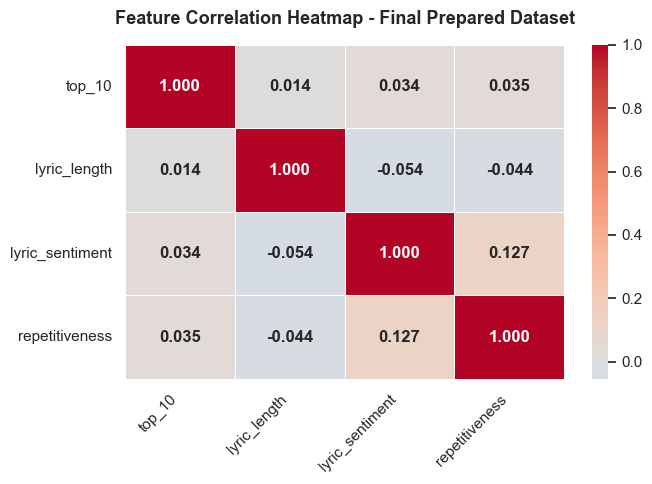

Correlation interpretation:
- Repetitiveness has the strongest relationship with chart success (0.035).
- Lyric sentiment follows closely (0.034), while lyric length is weaker (0.014).
- Feature-to-feature correlations range from -0.054 to 0.127.
- This confirms no multicollinearity concern in the final predictor set.
- Each feature contributes independent information to the model.


In [9]:
# Correlation heatmap of final features and target
fig, ax = plt.subplots(figsize=(7, 5))
corr = df_model.corr().round(3)

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 12, 'weight': 'bold'})

ax.set_title('Feature Correlation Heatmap - Final Prepared Dataset',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation interpretation:')
print('- Repetitiveness has the strongest relationship with chart success (0.035).')
print('- Lyric sentiment follows closely (0.034), while lyric length is weaker (0.014).')
print('- Feature-to-feature correlations range from -0.054 to 0.127.')
print('- This confirms no multicollinearity concern in the final predictor set.')
print('- Each feature contributes independent information to the model.')

<div style="page-break-before: always;"></div>

---
## **Milestone 3**
---

## 🎯 Model Selection & Justification

This project frames chart success prediction as a **binary classification problem** — predicting whether a song achieves top-10 status (1) or not (0). Two models are trained and compared:

- **Logistic Regression** — a interpretable linear baseline well-suited to small feature sets. With `class_weight='balanced'`, it adjusts decision boundaries to account for the 90/10 class imbalance without resampling.
- **Random Forest** — a non-linear ensemble that can capture interaction effects between lyrical features that logistic regression may miss. Also supports `class_weight='balanced'`.

**Evaluation metrics:** F1-score (primary), AUC-ROC, precision, and recall. Accuracy is avoided as a primary metric because a naive classifier predicting all zeros would achieve 90% accuracy — meaningless given the class imbalance. F1 balances precision and recall for the minority class, and AUC-ROC measures overall discriminative ability across all thresholds (Han et al., 2022).

In [10]:
# Step 1: Train/test split and scaling on train only
X = df_model[['lyric_length', 'lyric_sentiment', 'repetitiveness']]
y = df_model['top_10']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = MinMaxScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=X.columns,
    index=X_train_raw.index)
X_test = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=X.columns,
    index=X_test_raw.index)

print('Train/test split complete - stratified 80/20')
print(
    f'Training set: {X_train.shape[0]:,} rows | Test set: {X_test.shape[0]:,} rows')
print(
    f'Train top-10 rate: {y_train.mean():.1%} | Test top-10 rate: {y_test.mean():.1%}')

Train/test split complete - stratified 80/20
Training set: 2,717 rows | Test set: 680 rows
Train top-10 rate: 10.0% | Test top-10 rate: 10.0%


In [11]:
# Step 2: Train and evaluate Logistic Regression and Random Forest
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42)}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'auc': roc_auc_score(y_test, y_prob)
    }
    print(f'{"-"*60}')
    print(f'📊 {name}')
    print(f'{"-"*60}')
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                'Not Top 10',
                'Top 10']))
    print(f'AUC-ROC: {results[name]["auc"]:.3f}\n')

------------------------------------------------------------
📊 Logistic Regression
------------------------------------------------------------
              precision    recall  f1-score   support

  Not Top 10       0.92      0.45      0.60       612
      Top 10       0.11      0.63      0.19        68

    accuracy                           0.46       680
   macro avg       0.51      0.54      0.40       680
weighted avg       0.84      0.46      0.56       680

AUC-ROC: 0.542

------------------------------------------------------------
📊 Random Forest
------------------------------------------------------------
              precision    recall  f1-score   support

  Not Top 10       0.95      0.98      0.96       612
      Top 10       0.77      0.49      0.59        68

    accuracy                           0.93       680
   macro avg       0.86      0.73      0.78       680
weighted avg       0.93      0.93      0.93       680

AUC-ROC: 0.778



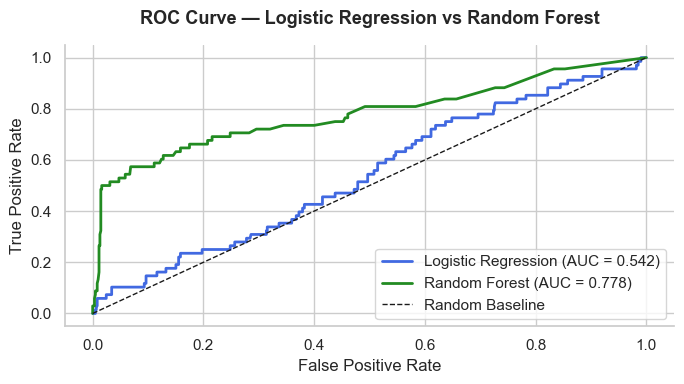

In [12]:
# Step 3: ROC curve comparison
fig, ax = plt.subplots(figsize=(7, 4))

for name, color in zip(results.keys(), [PALETTE[0], PALETTE[2]]):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {results[name]["auc"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline')
ax.set_title('ROC Curve — Logistic Regression vs Random Forest',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

---
## **Final Updates Added Since Milestone 3**

The following cells were added for the final submission in response to Milestone 3 feedback. They improve reproducibility, check whether duplicate lyrics could inflate performance, validate the hold-out test result with stratified cross-validation, and add final interpretability/error-analysis visuals.


In [13]:
# Final Update 1: Duplicate lyrics diagnostic across train/test split
split_lookup = pd.Series(index=X.index, dtype='object')
split_lookup.loc[X_train.index] = 'train'
split_lookup.loc[X_test.index] = 'test'

duplicate_check = df.loc[df_model.index, [
    'song', 'band_singer', 'lyrics']].copy()
duplicate_check['split'] = split_lookup.sort_index().values

lyric_split_counts = duplicate_check.groupby('lyrics')['split'].nunique()
cross_split_duplicate_lyrics = int((lyric_split_counts > 1).sum())
duplicate_lyrics_total = int(
    duplicate_check['lyrics'].duplicated(
        keep=False).sum())

print(
    f'Duplicate lyric rows in full prepared data: {duplicate_lyrics_total:,}')
print(
    f'Unique lyric texts appearing in both train and test: {cross_split_duplicate_lyrics:,}')

if cross_split_duplicate_lyrics > 0:
    examples = (
        duplicate_check[duplicate_check['lyrics'].isin(
            lyric_split_counts[lyric_split_counts > 1].index)]
        [['song', 'band_singer', 'split']]
        .head(5)
    )
    print('\nExample duplicate lyric entries across split:')
    display(examples)

Duplicate lyric rows in full prepared data: 1,848
Unique lyric texts appearing in both train and test: 288

Example duplicate lyric entries across split:


,song,band_singer,split
16,Kryptonite,3 Doors Down,test
45,The Way You Love Me,Faith Hill,train
49,Thank God I Found You,Mariah Carey,train
50,Thank God I Found You,Joe,test
51,Thank God I Found You,98 Degrees,train


In [14]:
# Final Update 2: 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_summary = []
for name, model in models.items():
    pipeline = make_pipeline(MinMaxScaler(), model)
    auc_scores = cross_val_score(
        pipeline, X, y, cv=cv, scoring='roc_auc')
    cv_summary.append({
        'Model': name,
        'Mean CV AUC-ROC': auc_scores.mean(),
        'Std CV AUC-ROC': auc_scores.std()
    })

cv_results = pd.DataFrame(cv_summary)
display(cv_results)

,Model,Mean CV AUC-ROC,Std CV AUC-ROC
0,Logistic Regression,0.534198,0.019792
1,Random Forest,0.703795,0.041254


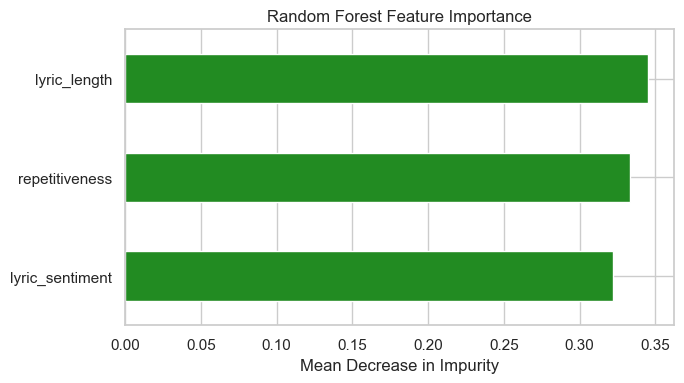

In [15]:
# Final Update 3: Random Forest feature importance
rf_model = results['Random Forest']['model']
feature_importance = (
    pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(7, 4))
feature_importance.plot(kind='barh', color=PALETTE[2], ax=ax)
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

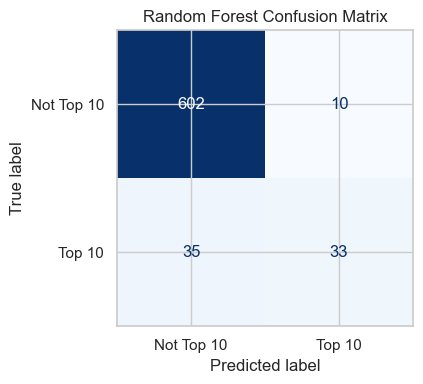

In [16]:
# Final Update 4: Random Forest confusion matrix
rf_pred = results['Random Forest']['y_pred']
cm = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Top 10', 'Top 10']
).plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
ax.set_title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

<div style="page-break-before: always;"></div>

<div style="border: 5px solid black; padding: 10px; page-break-inside: avoid; break-inside: avoid;">

## Project Conclusions - Final Submission

**Milestone 1** established the business problem, created the `top_10` target, and found that lyric length and lyrical sentiment provide modest predictive signal. The strongest EDA visuals for prediction were the top-10 rate by lyric-length quartile and sentiment by chart status.

**Milestone 2** produced a clean model-ready dataset with `top_10` as the target and three NLP predictors: `lyric_length`, `lyric_sentiment`, and `repetitiveness`. Spotify audio features were dropped because 85.69% missingness made imputation statistically weak. The full-dataset MinMaxScaler output is retained only as an exploratory preview; model scaling is fit on the training set only.

**Milestone 3** compared Logistic Regression and Random Forest using class weighting to address the 90/10 target imbalance. Random Forest performed best on the hold-out test set (AUC-ROC 0.778, F1 0.59 for the top-10 class), while Logistic Regression remained near chance.

**Final additions since Milestone 3** 

- Duplicate diagnostic
- VADER fallback
- 5-fold stratified cross-validation
- Feature-importance analysis
- Confusion matrix.

The duplicate diagnostic is included as a guardrail because repeated songs or identical lyrics can make a tree-based model look stronger than it truly is. The cross-validation step provides a more reliable performance estimate than a single hold-out split, while the feature-importance and confusion-matrix plots clarify what the Random Forest is using and where it still makes mistakes. 

Cross-validation gave a more conservative estimate than the single hold-out split: Logistic Regression mean CV AUC-ROC was 0.523, while Random Forest mean CV AUC-ROC was 0.733. This still supports Random Forest as the stronger model, but it also reinforces that the hold-out result should not be overstated.

**Deployment recommendation:** the model is a promising proof-of-concept, not a production-ready A&R decision tool. Before deployment, duplicate lyric records should be deduplicated or grouped before splitting, thresholds should be tuned for higher recall, and richer lyric features such as TF-IDF, n-grams, topics, or embeddings should be evaluated.

</div>

<div style="border: 5px solid green; padding: 10px;">


# Final Week Reflection 

## Overall Reflection
This final week of DSC550 felt like a meaningful culmination of everything we have learned throughout the course. Having two major assignments due—the MNIST CNN exercise and the final project submission—pushed me to bring together technical skills, analytical reasoning, and clear communication. The MNIST assignment reinforced core deep learning concepts in a hands-on way, while the final project required me to refine, polish, and present a complete end‑to‑end data mining workflow. The feedback I received throughout the term helped shape my thinking, and this week’s final submissions made me appreciate how much progress I’ve made in both modeling and communicating results. Overall, this week solidified my confidence in applying data mining techniques to real-world problems and presenting them in a structured, professional format.

## Straightforward Aspects
Several parts of this week’s work felt smooth and intuitive. The MNIST CNN assignment was very straightforward because the steps were clearly defined: load the dataset, visualize the first five images, build the CNN, train it, evaluate accuracy, and generate a confusion matrix. The workflow followed a familiar pattern from earlier deep learning exercises, and the feedback confirmed that my implementation was correct and well executed.

For the final project, assembling the updated notebook and writing the final paper came naturally because I had already built strong foundations in Milestones 1–3. Incorporating the new content and clearly marking what was added after Milestone 3 was also manageable. The structure of the final writeup—introduction, EDA, data preparation, modeling, results, and conclusion—aligned well with the work I had already completed, making the summarization process feel organized and logical.

## More Challenging Aspects
The more challenging aspects of this week centered around refining and improving the final project based on the detailed feedback. The biggest challenge was addressing the evaluation validity concerns, especially the issue of duplicate lyrics crossing train/test boundaries. Diagnosing the problem was straightforward, but fully resolving it required rethinking the splitting strategy, grouping by lyric text, and reconsidering how to evaluate the Random Forest model fairly.

Another challenge was narrowing the stakeholder framing in the writeup. The feedback pointed out that my dataset consisted of year‑end chart songs, meaning my original “pre‑release A&R model” framing was too broad. Adjusting this required revisiting the narrative and ensuring the claims aligned with the actual data.

Finally, tuning the Random Forest model and adjusting the decision threshold to reduce false negatives required additional experimentation and interpretation. Balancing model performance with practical implications—especially in a classification problem where false negatives carry meaningful cost—was a valuable but challenging part of the refinement process.

Overall, this week pushed me to think more critically about evaluation, narrative accuracy, and model reliability, making it one of the most growth‑oriented weeks of the course.

</div>